# ALICE, walked through: a 1D + 1D mutual-information example

This notebook follows the paper's inference story with scalar variables $X$ and $Y$. We will
build the exact rectified-flow velocity field for a correlated Gaussian, use three masks to
turn one field into the joint and conditional fields, and read mutual information from their
velocity gaps.

The notebook always loads the public ALICE checkpoint. The analytic Gaussian field is the
reference, and the trained model is evaluated on the same grid and with the same masks so their
vector fields, conditional slices, and MI integrands can be compared directly.

## The one sentence to remember

The **context** tells ALICE *which distribution* to represent. The **query** tells it *where*
to evaluate the velocity field. The mask says which coordinates are noised and which are held
clean as evidence.

The paper uses the rectified-flow convention $t=0$ for clean data and $t=1$ for Gaussian
noise.

In [46]:
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from tueplots import bundles, cycler
from tueplots.constants.color import palettes

# Use the same publication-oriented configuration family as the paper figures.
plt.rcParams.update(bundles.iclr2024(rel_width=0.95, ncols=1, family='sans serif'))
plt.rcParams.update({
    'text.usetex': False,
    'figure.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'grid.alpha': 0.22,
})
plt.rcParams.update(cycler.cycler(color=palettes.paultol_bright))

COLORS = {
    'context': "#2E75C7",
    'query': '#CC7711',
    'noise': '#8844AA',
    'clean': '#117733',
    'field': '#4477AA',
    'conditional': '#CC3311',
    'error': '#AA3377',
}

SEED = 17
torch.set_default_dtype(torch.float64)
torch.manual_seed(SEED)
np.random.seed(SEED)
print('PyTorch:', torch.__version__)

PyTorch: 2.14.0


## 1. A concrete 1D + 1D distribution

Let $Z=(X,Y)$ be a zero-mean Gaussian with unit marginal variances and correlation $\rho$.
For this example the true mutual information is known exactly:

$$I(X;Y)=-\frac{1}{2}\log\left(1-\rho^2\right)\quad\text{nats}. $$

The sample cloud below is the context-sized object that tells an in-context model what
distribution it is looking at.

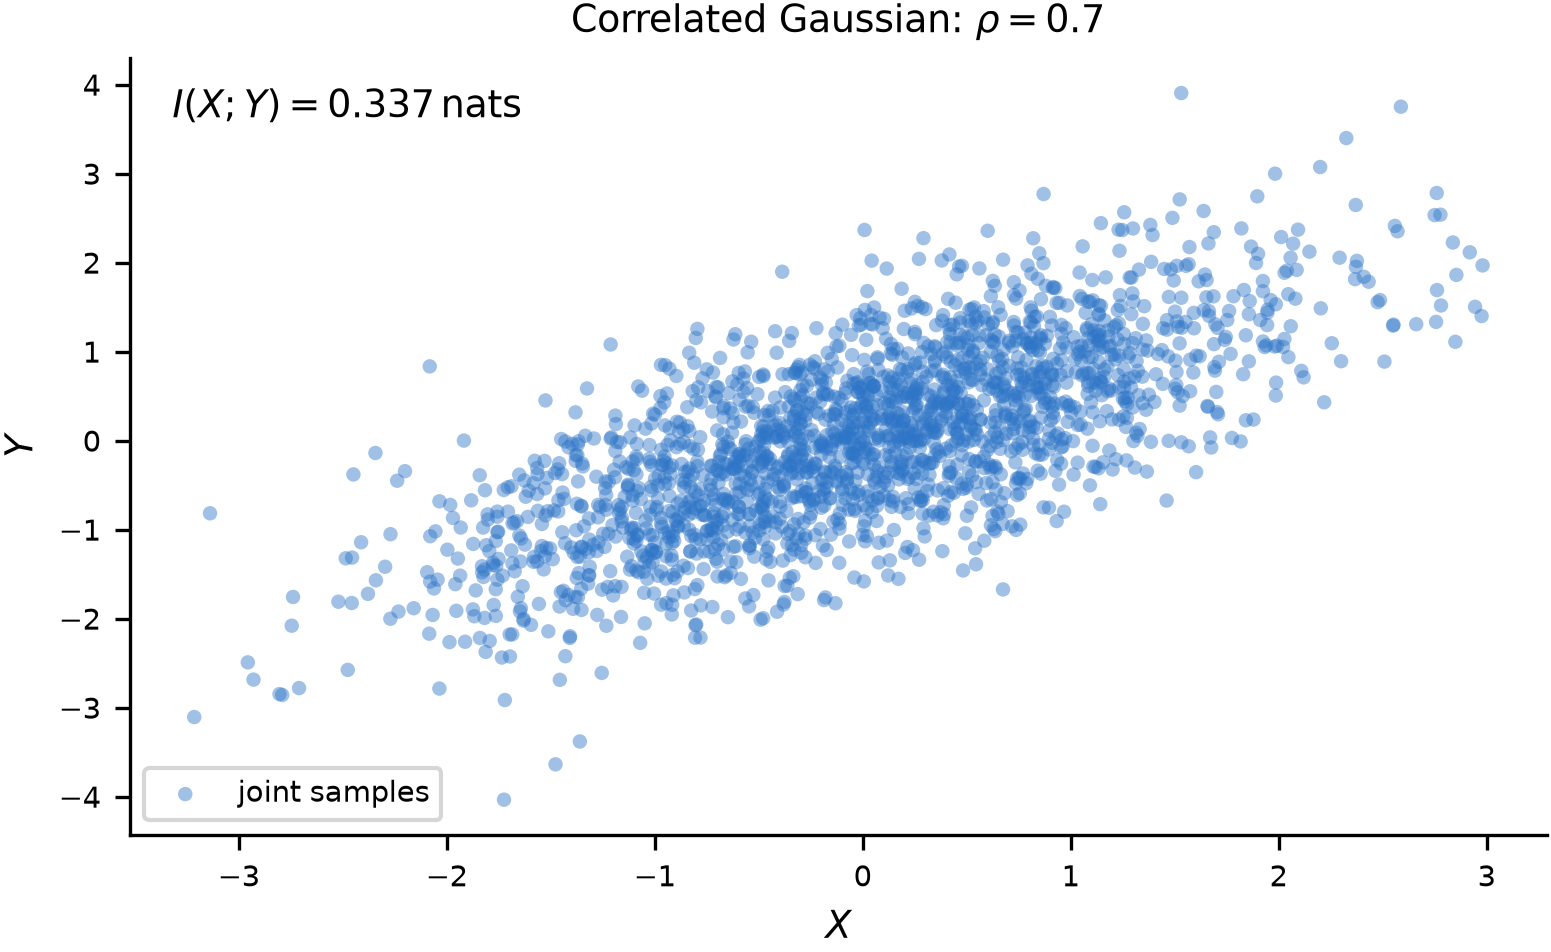

In [47]:
rho = 0.7
sigma = torch.tensor([[1.0, rho], [rho, 1.0]])
chol = torch.linalg.cholesky(sigma)
sample_generator = torch.Generator().manual_seed(SEED)
samples = torch.randn((2048, 2), generator=sample_generator) @ chol.T
true_mi = -0.5 * math.log1p(-rho**2)

fig, ax = plt.subplots()
ax.scatter(samples[:, 0], samples[:, 1], s=12, alpha=0.45, color=COLORS['context'],
           edgecolors='none', label='joint samples')
ax.set(xlabel=r'$X$', ylabel=r'$Y$', title=fr'Correlated Gaussian: $\rho = {rho:.1f}$')
ax.legend()
ax.text(0.03, 0.96, fr'$I(X;Y) = {true_mi:.3f}\,\mathrm{{nats}}$',
        transform=ax.transAxes, va='top')
plt.show()

## 2. The exact rectified-flow velocity field

The forward process linearly interpolates between a clean point and Gaussian noise:

$$z_t=(1-t)z_0+t\,\varepsilon.$$

The velocity field is the conditional average of the straight-line target $z_0-\varepsilon$.
For this Gaussian example it is available in closed form. If $\Sigma$ is the covariance of
$z_0$, then the row-vector implementation below evaluates

$$v_t(z)=\left((1-t)\Sigma-tI\right)\left((1-t)^2\Sigma+t^2I\right)^{-1}z.$$

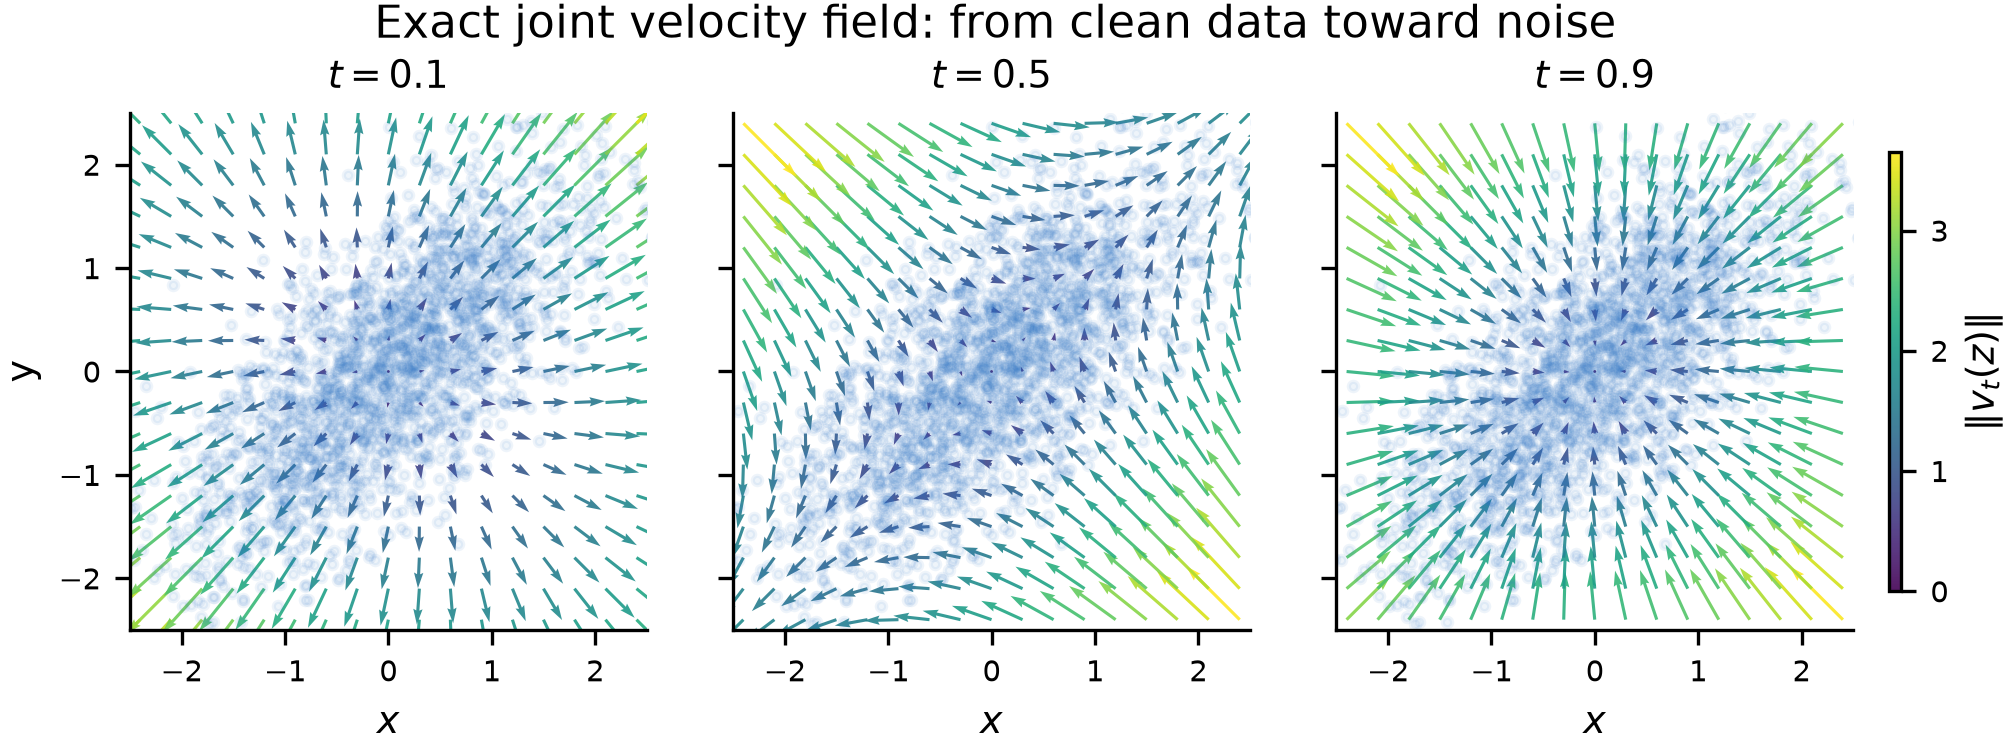

In [48]:
def covariance(rho_value):
    return torch.tensor([[1.0, rho_value], [rho_value, 1.0]])


def exact_joint_velocity(z, t, rho_value):
    z = torch.as_tensor(z)
    sigma_value = covariance(rho_value).to(dtype=z.dtype, device=z.device)
    eye = torch.eye(2, dtype=z.dtype, device=z.device)
    a = 1.0 - float(t)
    operator = (a * sigma_value - float(t) * eye) @ torch.linalg.inv(
        a * a * sigma_value + float(t) * float(t) * eye
    )
    return z @ operator.T


def exact_conditional_velocity(q, t, condition, rho_value):
    # q is the noised scalar; condition is the other clean scalar.
    q = torch.as_tensor(q)
    condition = torch.as_tensor(condition, dtype=q.dtype, device=q.device)
    variance = 1.0 - rho_value * rho_value
    mean = rho_value * condition
    a = 1.0 - float(t)
    denominator = a * a * variance + float(t) * float(t)
    slope = (a * variance - float(t)) / denominator
    return mean + slope * (q - a * mean)


def grid_points(limit=2.4, steps=17):
    axis = torch.linspace(-limit, limit, steps)
    xx, yy = torch.meshgrid(axis, axis, indexing='xy')
    points = torch.stack((xx.reshape(-1), yy.reshape(-1)), dim=-1)
    return axis, xx, yy, points


axis, xx, yy, grid = grid_points()
time_slices = (0.1, 0.5, 0.9)
exact_fields = [exact_joint_velocity(grid, t_value, rho).reshape(xx.shape + (2,))
                for t_value in time_slices]
exact_speeds = [torch.linalg.vector_norm(velocity, dim=-1) for velocity in exact_fields]
field_scale = max(float(torch.stack(exact_speeds).max()), 0.5)

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5), sharex=True, sharey=True,
                         layout='constrained')
for ax, t_value, velocity, speed in zip(axes, time_slices, exact_fields, exact_speeds):
    arrows = ax.quiver(xx, yy, velocity[..., 0], velocity[..., 1], speed,
                       cmap='viridis', angles='xy',
                       scale_units='xy', scale=5, alpha=0.9, width=0.006)
    arrows.set_clim(0, field_scale)
    ax.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.08, color=COLORS['context'])
    ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), xlabel=r'$x$',
           title=fr'$t = {t_value:.1f}$')
    ax.set_aspect('equal')
axes[0].set_ylabel('y')
fig.colorbar(arrows, ax=axes, label=r'$\|v_t(z)\|$', shrink=0.85,
             fraction=0.03, pad=0.02, aspect=35)
fig.suptitle('Exact joint velocity field: from clean data toward noise')
plt.show()

The joint field is two-dimensional, but the conditional fields are one-dimensional in this
1D + 1D example. Holding $Y=y_0$ clean gives the field for $X\mid Y=y_0$; holding $X=x_0$
clean gives the field for $Y\mid X=x_0$. The next plot compares those conditional curves with
a slice through the joint field.

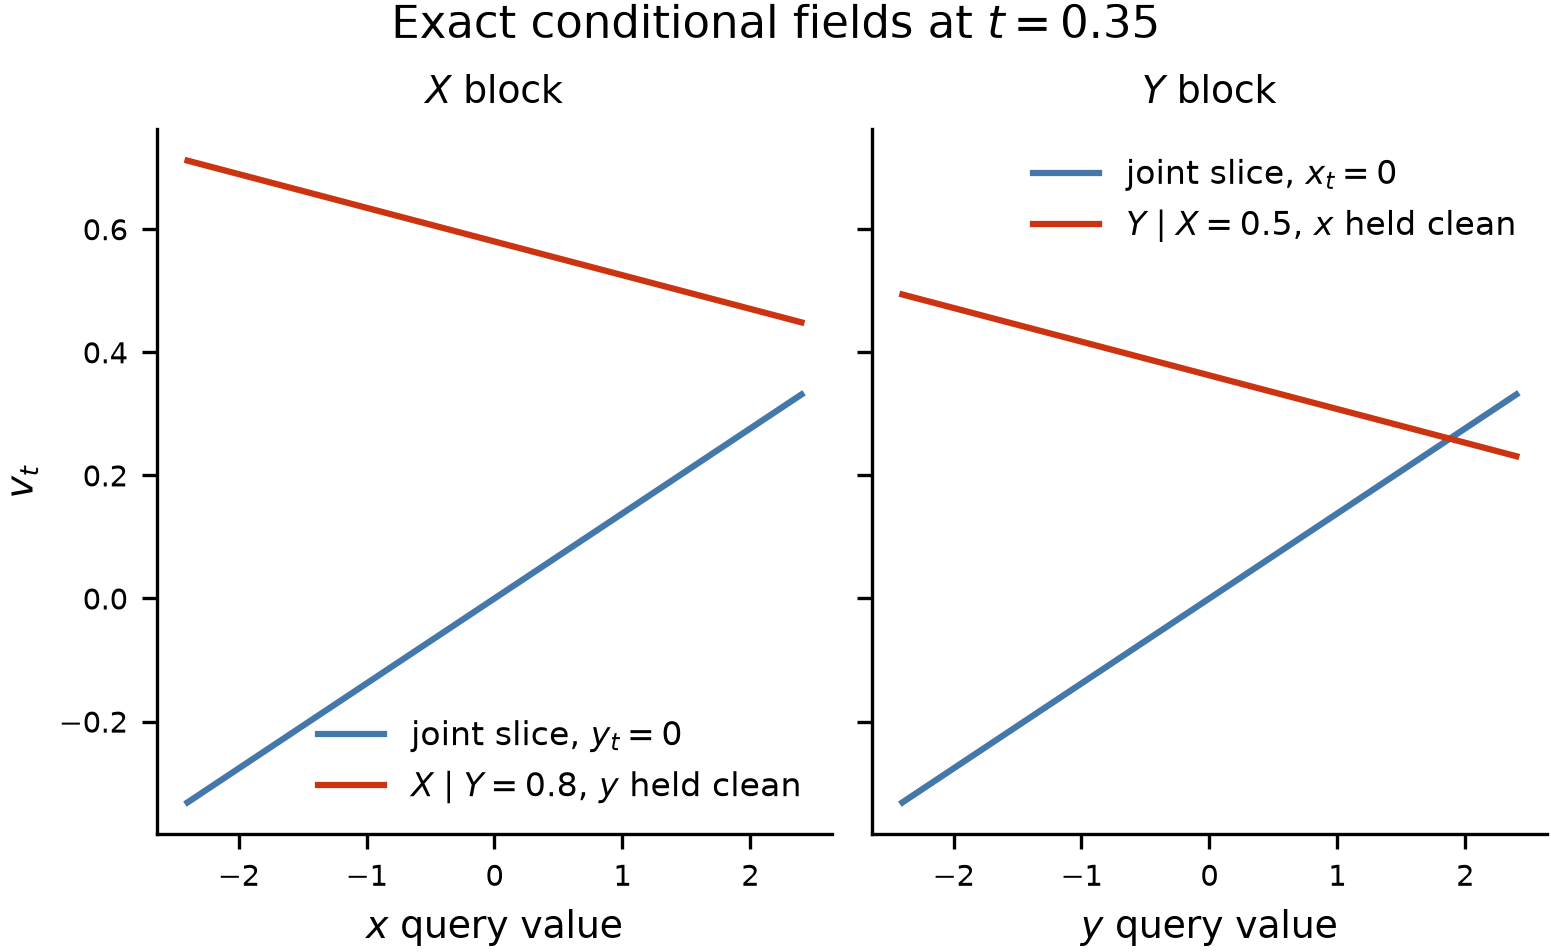

In [49]:
t_slice = 0.35
condition_x0 = 0.8
condition_y0 = 0.5
scalar_grid = torch.linspace(-2.4, 2.4, 300)
joint_x_slice = exact_joint_velocity(
    torch.stack((scalar_grid, torch.zeros_like(scalar_grid)), dim=-1), t_slice, rho
)[:, 0]
joint_y_slice = exact_joint_velocity(
    torch.stack((torch.zeros_like(scalar_grid), scalar_grid), dim=-1), t_slice, rho
)[:, 1]
conditional_x = exact_conditional_velocity(scalar_grid, t_slice, condition_x0, rho)
conditional_y = exact_conditional_velocity(scalar_grid, t_slice, condition_y0, rho)

fig, axes = plt.subplots(1, 2, sharey=True, layout='constrained')
axes[0].plot(scalar_grid, joint_x_slice, color=COLORS['field'], label=r'joint slice, $y_t=0$')
axes[0].plot(scalar_grid, conditional_x, color=COLORS['conditional'],
              label=fr'$X\mid Y={condition_x0:.1f}$, $y$ held clean')
axes[0].set(xlabel=r'$x$ query value', ylabel=r'$v_t$', title=r'$X$ block')
axes[0].legend(frameon=False, fontsize=8)
axes[1].plot(scalar_grid, joint_y_slice, color=COLORS['field'], label=r'joint slice, $x_t=0$')
axes[1].plot(scalar_grid, conditional_y, color=COLORS['conditional'],
              label=fr'$Y\mid X={condition_y0:.1f}$, $x$ held clean')
axes[1].set(xlabel=r'$y$ query value', title=r'$Y$ block')
axes[1].legend(frameon=False, fontsize=8)
fig.suptitle(fr'Exact conditional fields at $t = {t_slice:.2f}$')
plt.show()

## 3. One noisy point, three masked questions

For one evaluation point we draw one $\varepsilon$ and one $t$. The same noise realization is
shared by all three queries. Only the noising mask and the corresponding query coordinates
change. These three evaluations are needed because the MI identity is a comparison: it
needs the joint prediction and both one-coordinate conditional predictions at the same
point, time, and noise realization. Reusing the noise makes the squared velocity gaps
measure the effect of revealing the other coordinate, rather than differences caused by
three unrelated random draws.

- $(1,1)$ asks for the joint field.
- $(1,0)$ noises $X$ and holds clean $Y$, giving $X\mid Y$.
- $(0,1)$ noises $Y$ and holds clean $X$, giving $Y\mid X$.

The mask is therefore not three alternative visualizations of one point: it is the
minimal set of masked questions from which ALICE can form both conditional-vs-joint
velocity gaps, and those gaps are what the MI estimator integrates.

In [50]:
z0 = torch.tensor([0.70, 0.50])
epsilon = torch.tensor([-1.20, 0.40])
t_demo = 0.30
zt = (1.0 - t_demo) * z0 + t_demo * epsilon

queries = {
    'joint': zt,
    'X | Y': torch.tensor([zt[0], z0[1]]),
    'Y | X': torch.tensor([z0[0], zt[1]]),
}
masks = torch.tensor([[1, 1], [1, 0], [0, 1]], dtype=torch.float64)
print(f'z0 = {z0.tolist()}')
print(f'epsilon = {epsilon.tolist()}')
print(f't = {t_demo}, z_t = {zt.tolist()}')
for name, query in queries.items():
    print(f'{name:>6}: query = {query.tolist()}')
print('mask convention: 1 = coordinate is noised; 0 = coordinate is held clean')
for name, mask in zip(('joint', 'X | Y', 'Y | X'), masks.tolist()):
    print(f'{name:>6}: mask = {mask}')

z0 = [0.7, 0.5]
epsilon = [-1.2, 0.4]
t = 0.3, z_t = [0.12999999999999995, 0.47]
 joint: query = [0.12999999999999995, 0.47]
 X | Y: query = [0.12999999999999995, 0.5]
 Y | X: query = [0.7, 0.47]
mask convention: 1 = coordinate is noised; 0 = coordinate is held clean
 joint: mask = [1.0, 1.0]
 X | Y: mask = [1.0, 0.0]
 Y | X: mask = [0.0, 1.0]


## 4. MI is the weighted velocity-gap integral

At each $(z_0,\varepsilon,t)$ we compare the joint field with the matching conditional field
on the block that was noised. The paper's identity is

$$I(X;Y)=\int_0^1\frac{1-t}{t}\left(\left\|v_{\mathrm{full}}-v_{X\mid Y}\right\|_X^2+\left\|v_{\mathrm{full}}-v_{Y\mid X}\right\|_Y^2\right)\,\mathrm{d}t.$$

closed-form MI: 0.3367 nats
velocity-gap integral on this finite grid: 0.3404 nats


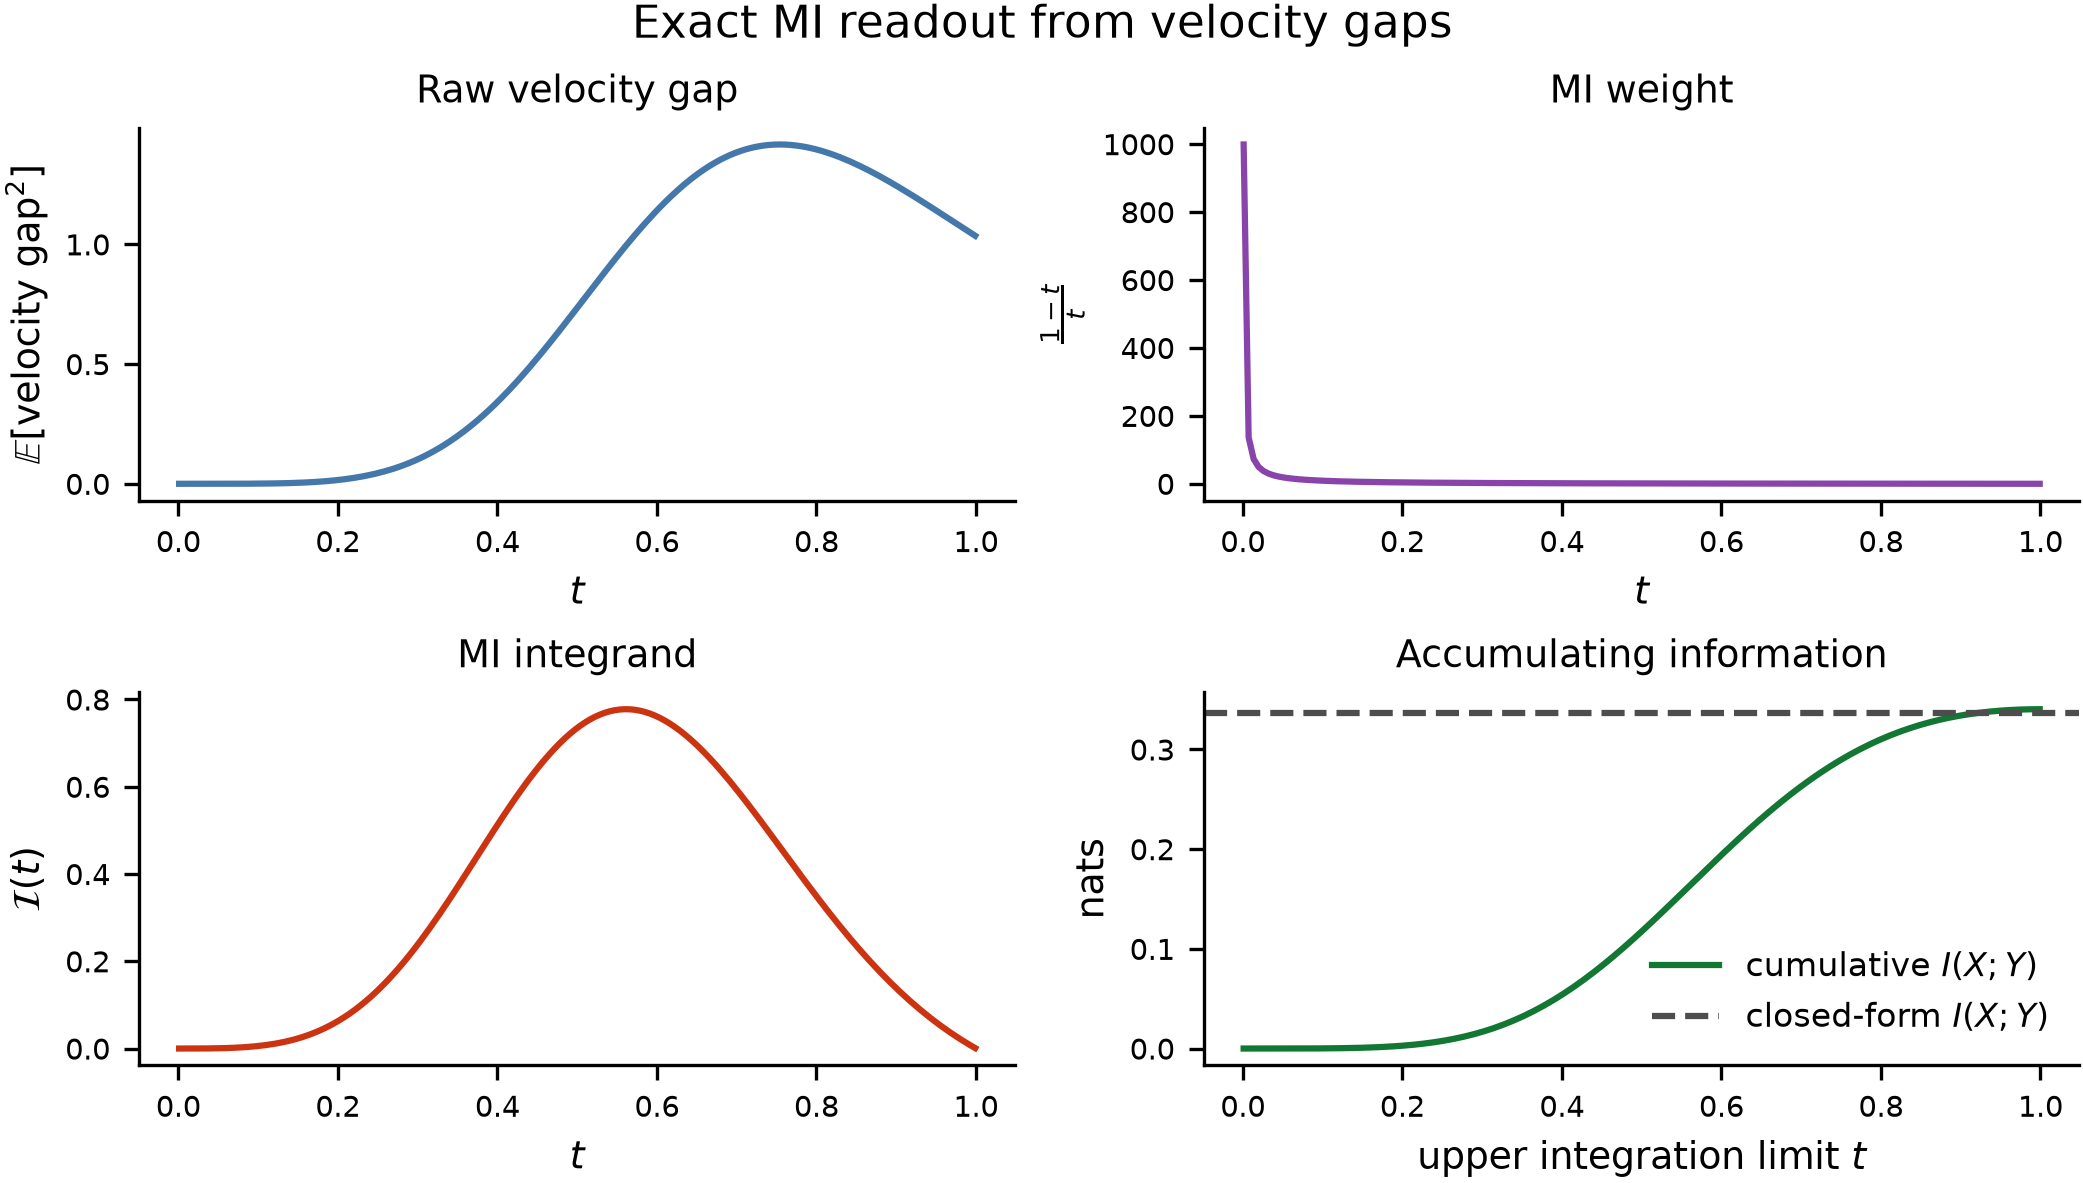

In [51]:
def exact_gap_curves(t_grid, z0_values, epsilon_values, rho_value):
    gap_values = []
    for t_value in t_grid:
        t_column = torch.full((z0_values.shape[0], 1), float(t_value))
        z_full = (1.0 - t_column) * z0_values + t_column * epsilon_values
        z_x = z0_values.clone()
        z_x[:, 0] = z_full[:, 0]
        z_y = z0_values.clone()
        z_y[:, 1] = z_full[:, 1]
        v_full = exact_joint_velocity(z_full, t_value, rho_value)
        v_x = torch.stack((exact_conditional_velocity(z_full[:, 0], t_value, z0_values[:, 1], rho_value),
                           torch.zeros_like(z_full[:, 1])), dim=-1)
        v_y = torch.stack((torch.zeros_like(z_full[:, 0]),
                           exact_conditional_velocity(z_full[:, 1], t_value, z0_values[:, 0], rho_value)), dim=-1)
        gap = (v_full[:, 0] - v_x[:, 0]).square() + (v_full[:, 1] - v_y[:, 1]).square()
        gap_values.append(gap.mean())
    gaps = torch.stack(gap_values)
    weights = (1.0 - t_grid) / t_grid
    return gaps, weights, gaps * weights


def cumulative_trapezoid(x, y):
    increments = 0.5 * (y[1:] + y[:-1]) * (x[1:] - x[:-1])
    return torch.cat((torch.zeros(1), torch.cumsum(increments, dim=0)))

eval_generator = torch.Generator().manual_seed(SEED + 1)
eval_z0 = torch.randn((512, 2), generator=eval_generator) @ chol.T
eval_epsilon = torch.randn((512, 2), generator=eval_generator)
t_grid = torch.linspace(0.001, 0.999, 160)
gaps, weights, integrand = exact_gap_curves(t_grid, eval_z0, eval_epsilon, rho)
cumulative_mi = cumulative_trapezoid(t_grid, integrand)
mi_from_grid = torch.trapezoid(integrand, t_grid).item()
print(f'closed-form MI: {true_mi:.4f} nats')
print(f'velocity-gap integral on this finite grid: {mi_from_grid:.4f} nats')

fig, axes = plt.subplots(2, 2, figsize=(7, 4), layout='constrained')
axes[0, 0].plot(t_grid, gaps, color=COLORS['field'])
axes[0, 0].set(xlabel=r'$t$', ylabel=r'$\mathbb{E}[\text{velocity gap}^2]$',
                   title='Raw velocity gap')
axes[0, 1].plot(t_grid, weights, color=COLORS['noise'])
axes[0, 1].set(xlabel=r'$t$', ylabel=r'$\frac{1-t}{t}$', title='MI weight')
axes[1, 0].plot(t_grid, integrand, color=COLORS['conditional'])
axes[1, 0].set(xlabel=r'$t$', ylabel=r'$\mathcal{I}(t)$', title='MI integrand')
axes[1, 1].plot(t_grid, cumulative_mi, color=COLORS['clean'],
                    label=r'cumulative $I(X;Y)$')
axes[1, 1].axhline(true_mi, color='0.3', ls='--',
                    label=r'closed-form $I(X;Y)$')
axes[1, 1].set(xlabel=r'upper integration limit $t$', ylabel=r'$\mathrm{nats}$',
                   title='Accumulating information')
axes[1, 1].legend(frameon=False, fontsize=8)
fig.suptitle('Exact MI readout from velocity gaps')
plt.show()

## 5. Compare the exact field with trained ALICE

This section always loads the public checkpoint, binds it to a finite context, and evaluates
the exact same grid and masks used above. The learned field is expected to be approximate: it
is conditioned on a finite context and comes from a frozen model trained over an atlas of
distributions.

The figure **Exact and learned conditional fields at $t=t_{\mathrm{field}}$** is a pair of one-dimensional
slices. In the left panel, the horizontal axis is a possible noisy $X$ query and the vertical
axis is its velocity; in the right panel the same is shown for $Y$. Solid curves are the
analytic Gaussian reference and dashed curves are ALICE predictions. The blue curves use the
joint mask $(1,1)$ and show a slice of the two-dimensional joint field. The red curves use
the conditional masks $(1,0)$ or $(0,1)$, holding the other coordinate clean at the fixed
value $\texttt{condition}$. Thus, the gap between the red and blue curves is the coordinate-wise
velocity difference that later contributes to the MI integrand.

In [52]:
from alice import estimate_mi_minde, load_model, velocity_field_masked

model = load_model('eurecom-probai/alice-small-stage2', device='cpu')
model_samples = samples.float()
context = model_samples
evaluation_generator = torch.Generator().manual_seed(SEED + 2)
evaluation_samples = torch.randn((1024, 2), generator=evaluation_generator).float() @ chol.float().T
field = velocity_field_masked(model, context, device='cpu', chunk=128)
print(f'loaded {type(model).__name__} with context shape {tuple(context.shape)}')
print('The model is frozen; all following values are forward-pass field evaluations.')

Loading weights: 100%|██████████| 183/183 [00:00<00:00, 18557.52it/s]

loaded InducedGroupICLDenoiserModel with context shape (2048, 2)
The model is frozen; all following values are forward-pass field evaluations.


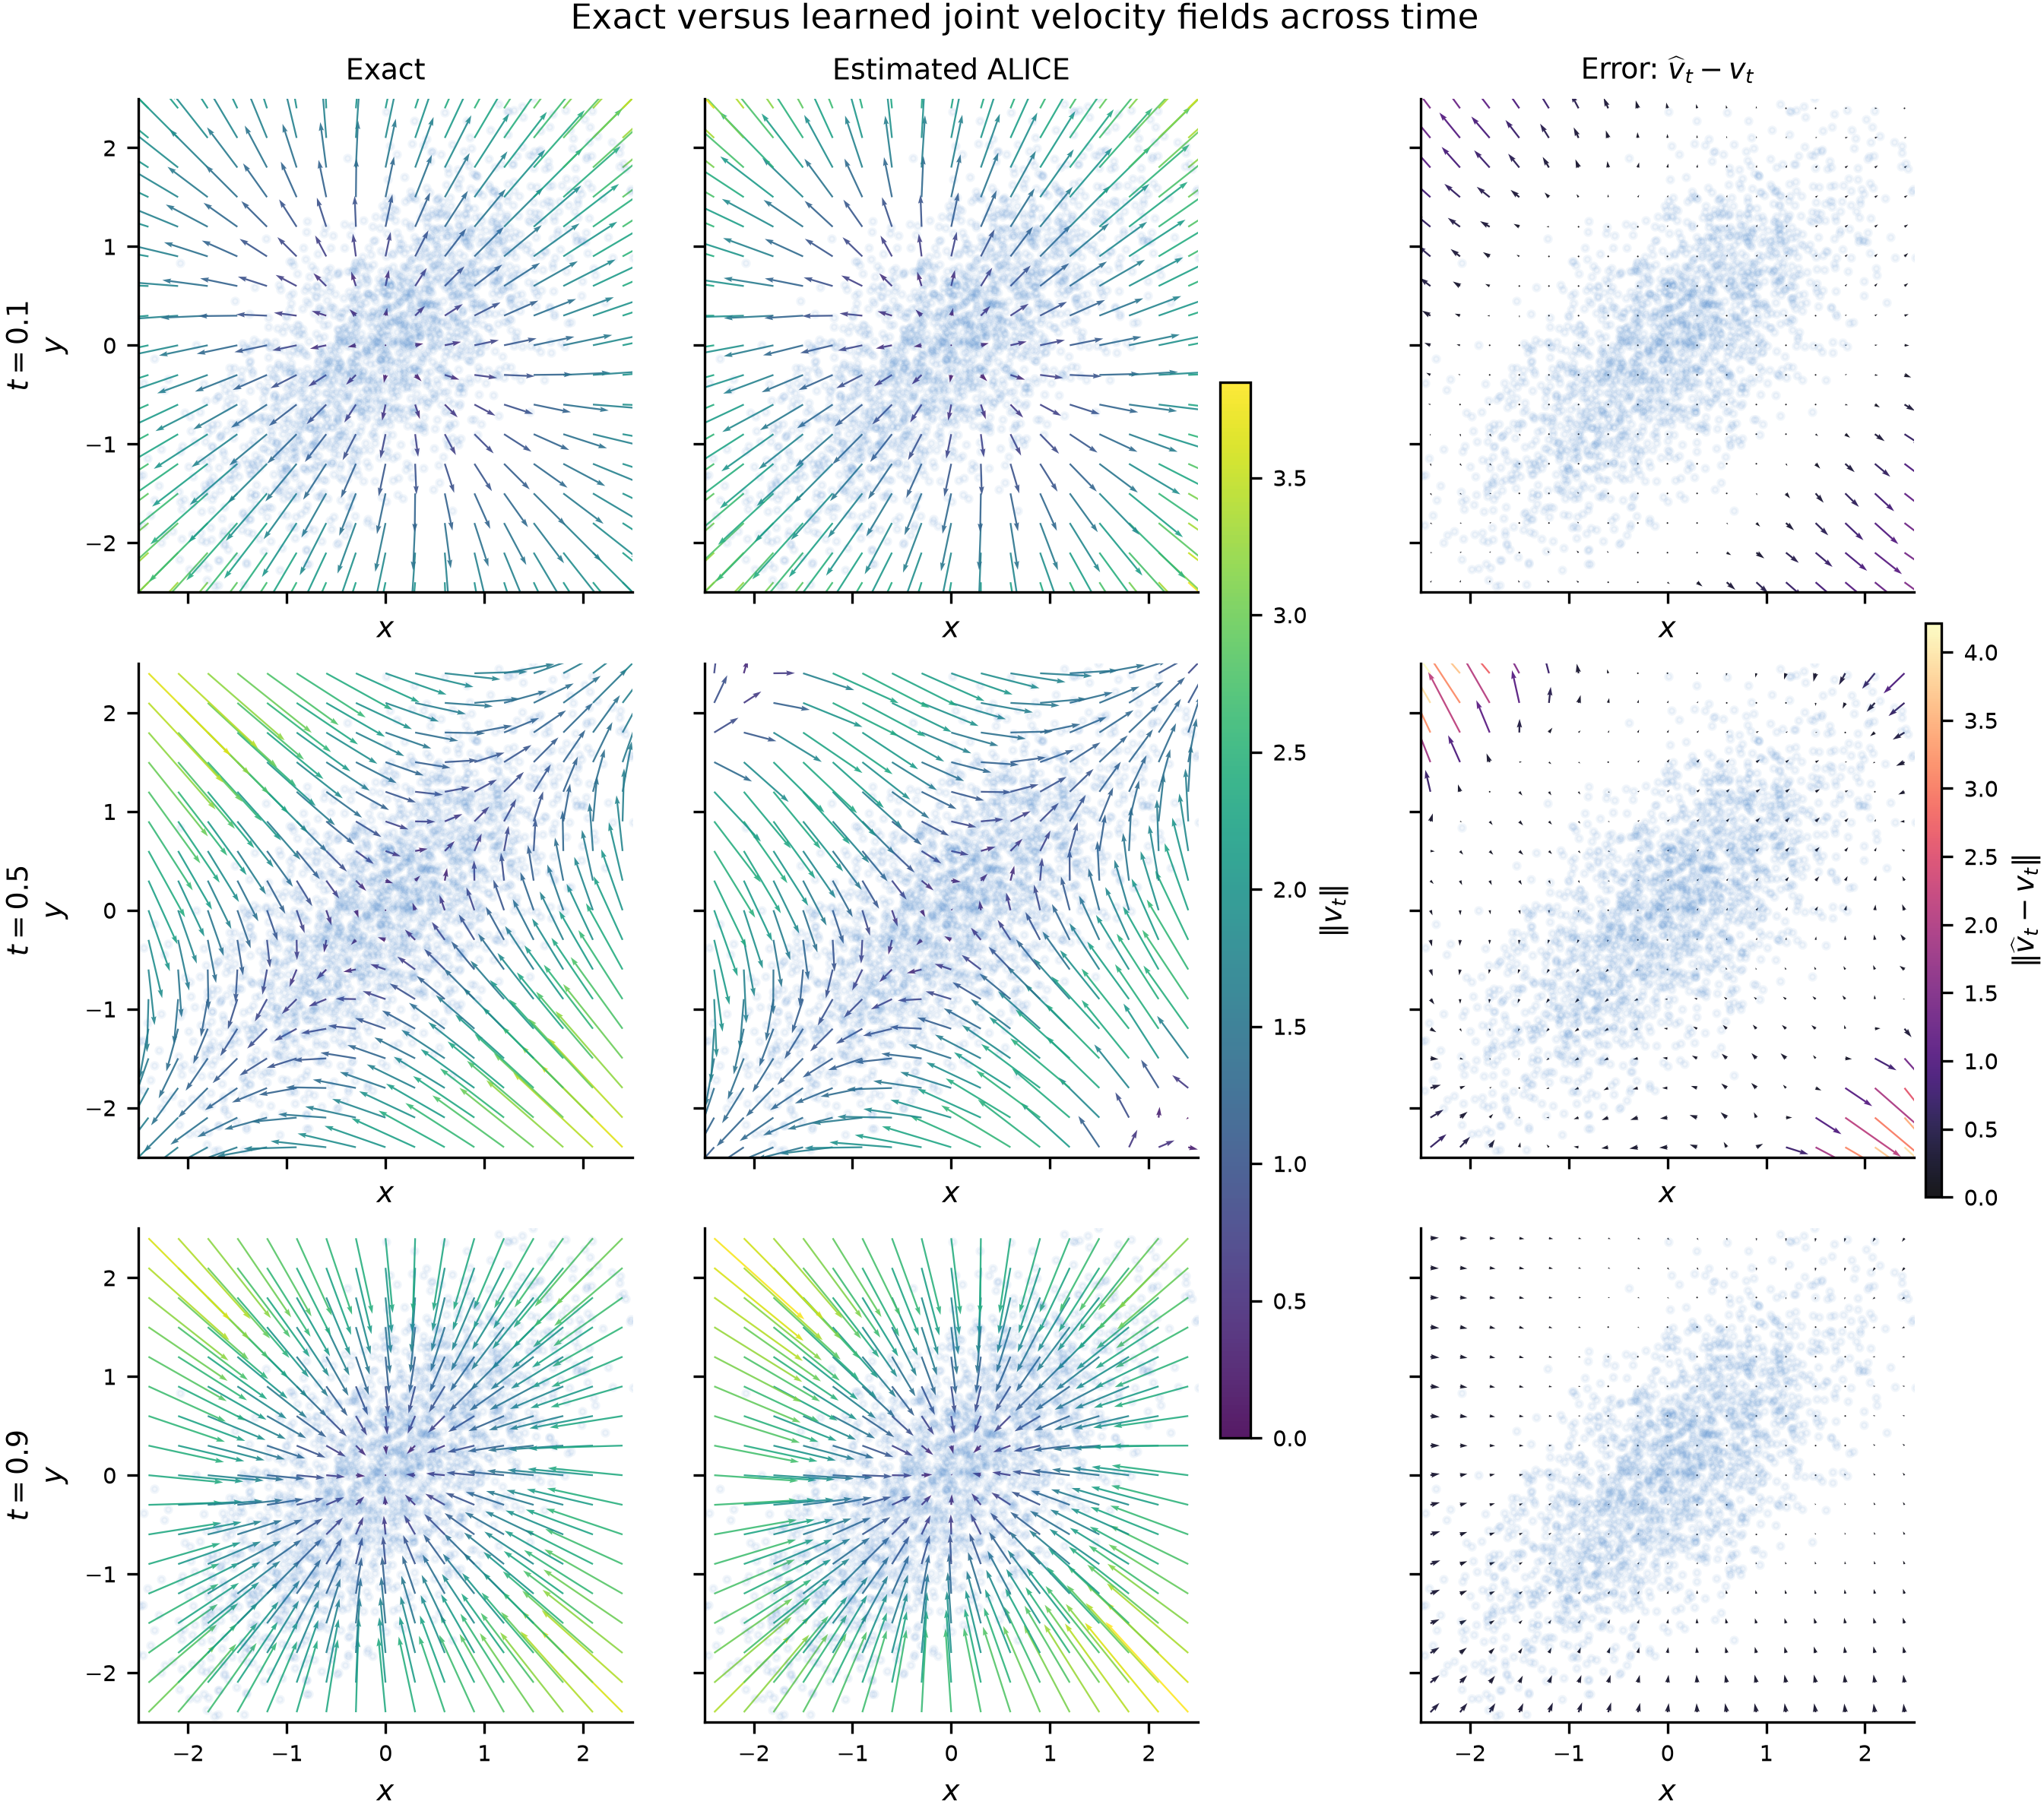

mean vector-field errors: [0.19916029274463654, 0.3571488559246063, 0.13601744174957275]


In [53]:
comparison_times = time_slices
t_field = 0.6
model_grid = grid.float()
comparison_results = []
for t_value in comparison_times:
    model_velocity = field(
        model_grid,
        torch.full((model_grid.shape[0], 1), t_value),
        torch.ones(2),
    ).reshape(xx.shape + (2,))
    exact_velocity = exact_joint_velocity(grid, t_value, rho).reshape(xx.shape + (2,)).float()
    difference = model_velocity - exact_velocity
    comparison_results.append((exact_velocity, model_velocity, difference))

field_scale = max(float(torch.stack([
    torch.linalg.vector_norm(values, dim=-1)
    for exact_value, model_value, _ in comparison_results
    for values in (exact_value, model_value)
]).max()), 0.5)
error_scale = max(float(torch.stack([
    torch.linalg.vector_norm(difference, dim=-1)
    for _, _, difference in comparison_results
]).max()), 1e-6)

fig, axes = plt.subplots(3, 3, figsize=(9, 8), sharex=True, sharey=True,
                         layout='constrained')
column_specs = (
    ('Exact', 'viridis', field_scale),
    ('Estimated ALICE', 'viridis', field_scale),
    (r'Error: $\widehat{v}_t-v_t$', 'magma', error_scale),
)
for row, (t_value, (exact_value, model_value, difference)) in enumerate(
        zip(comparison_times, comparison_results)):
    values_by_column = (exact_value, model_value, difference)
    for col, ((column_title, cmap, vmax), values) in enumerate(
            zip(column_specs, values_by_column)):
        magnitude = torch.linalg.vector_norm(values, dim=-1)
        arrows = axes[row, col].quiver(
            xx, yy, values[..., 0], values[..., 1], magnitude, cmap=cmap,
            angles='xy', scale_units='xy', scale=3.1, alpha=0.9
        )
        arrows.set_clim(0, vmax)
        axes[row, col].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.06,
                               color=COLORS['context'])
        axes[row, col].set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), xlabel=r'$x$')
        axes[row, col].set_aspect('equal')
        if row == 0:
            axes[row, col].set_title(column_title)
        if col == 0:
            axes[row, col].set_ylabel(f'$t = {t_value:.1f}$\n$y$')
        if col < 2:
            field_arrows = arrows
        else:
            error_arrows = arrows
fig.colorbar(field_arrows, ax=axes[:, :2].ravel().tolist(), shrink=0.65,
             fraction=0.03, pad=0.02, aspect=35, label=r'$\|v_t\|$')
fig.colorbar(error_arrows, ax=axes[:, 2].ravel().tolist(), shrink=0.65,
             fraction=0.03, pad=0.02, aspect=35,
             label=r'$\|\widehat{v}_t-v_t\|$')
fig.suptitle('Exact versus learned joint velocity fields across time')
plt.show()
print('mean vector-field errors:', [
    float(torch.linalg.vector_norm(difference, dim=-1).mean())
    for _, _, difference in comparison_results
])


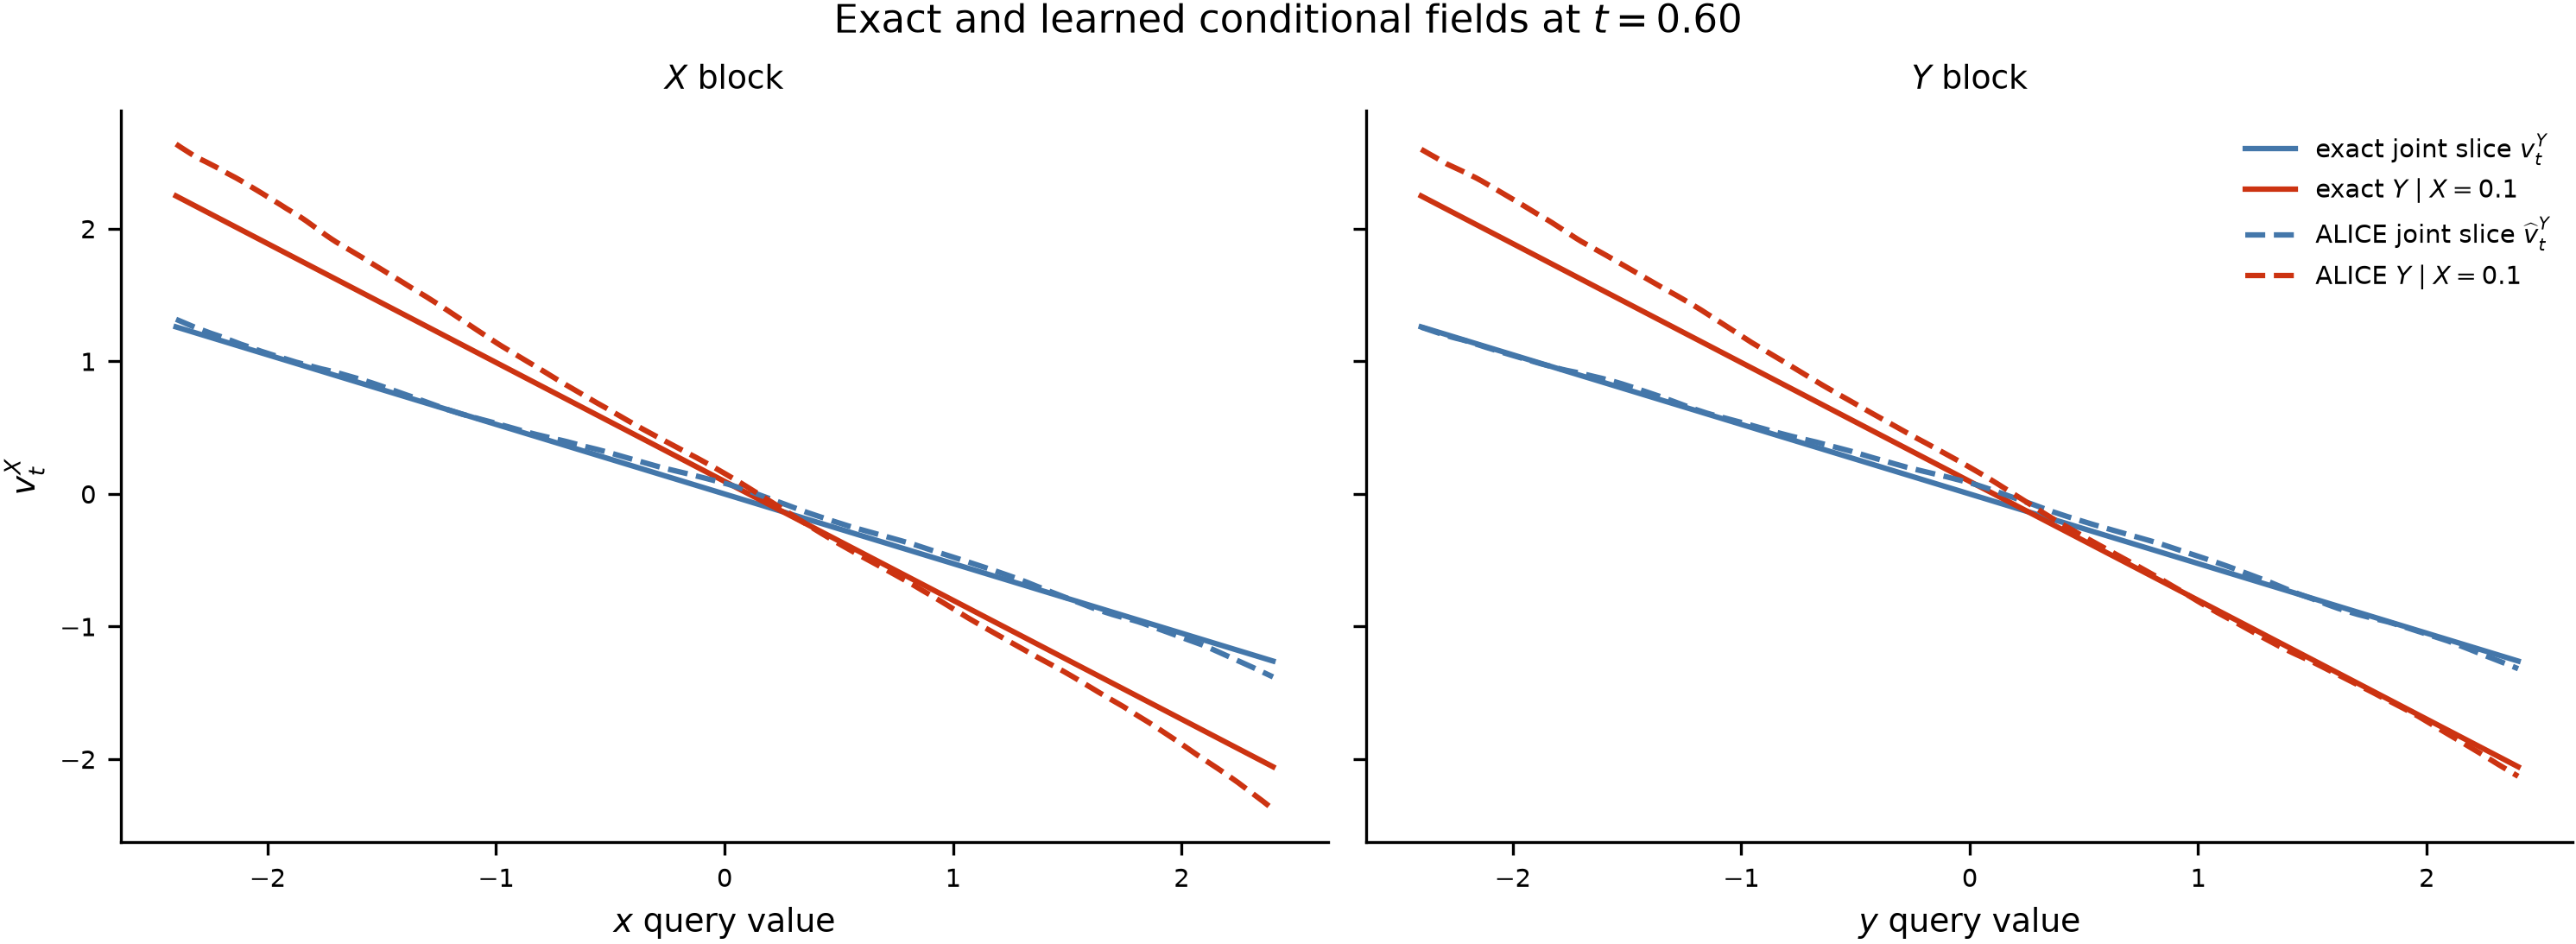

In [54]:
condition = 0.1
curve_grid = torch.linspace(-2.4, 2.4, 220)
full_x_query = torch.stack((curve_grid, torch.zeros_like(curve_grid)), dim=-1)
cond_x_query = torch.stack((curve_grid, torch.full_like(curve_grid, condition)), dim=-1)
full_y_query = torch.stack((torch.zeros_like(curve_grid), curve_grid), dim=-1)
cond_y_query = torch.stack((torch.full_like(curve_grid, condition), curve_grid), dim=-1)
time_column = torch.full((curve_grid.shape[0], 1), t_field)
all_mask = torch.ones(2)
x_mask = torch.tensor([1.0, 0.0])
y_mask = torch.tensor([0.0, 1.0])

learned_full_x = field(full_x_query, time_column, all_mask)[:, 0]
learned_cond_x = field(cond_x_query, time_column, x_mask)[:, 0]
learned_full_y = field(full_y_query, time_column, all_mask)[:, 1]
learned_cond_y = field(cond_y_query, time_column, y_mask)[:, 1]
exact_full_x = exact_joint_velocity(full_x_query, t_field, rho)[:, 0]
exact_cond_x = exact_conditional_velocity(curve_grid, t_field, condition, rho)
exact_full_y = exact_joint_velocity(full_y_query, t_field, rho)[:, 1]
exact_cond_y = exact_conditional_velocity(curve_grid, t_field, condition, rho)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), sharey=True, layout='constrained')
axes[0].plot(curve_grid, exact_full_x, color=COLORS['field'],
              label=r'exact joint slice $v_t^X$')
axes[0].plot(curve_grid, exact_cond_x, color=COLORS['conditional'],
              label=fr'exact $X\mid Y={condition:.1f}$')
axes[0].plot(curve_grid, learned_full_x, color=COLORS['field'], ls='--',
              label=r'ALICE joint slice $\widehat{v}_t^X$')
axes[0].plot(curve_grid, learned_cond_x, color=COLORS['conditional'], ls='--',
              label=fr'ALICE $X\mid Y={condition:.1f}$')
axes[0].set(xlabel=r'$x$ query value', ylabel=r'$v_t^X$', title=r'$X$ block')
axes[1].plot(curve_grid, exact_full_y, color=COLORS['field'],
              label=r'exact joint slice $v_t^Y$')
axes[1].plot(curve_grid, exact_cond_y, color=COLORS['conditional'],
              label=fr'exact $Y\mid X={condition:.1f}$')
axes[1].plot(curve_grid, learned_full_y, color=COLORS['field'], ls='--',
              label=r'ALICE joint slice $\widehat{v}_t^Y$')
axes[1].plot(curve_grid, learned_cond_y, color=COLORS['conditional'], ls='--',
              label=fr'ALICE $Y\mid X={condition:.1f}$')
axes[1].set(xlabel=r'$y$ query value', title=r'$Y$ block')
axes[1].legend(frameon=False, fontsize=7)
fig.suptitle(fr'Exact and learned conditional fields at $t = {t_field:.2f}$')
plt.show()


ALICE estimate from public API: 0.4155 +/- 0.0055 nats
closed-form reference: 0.3367 nats


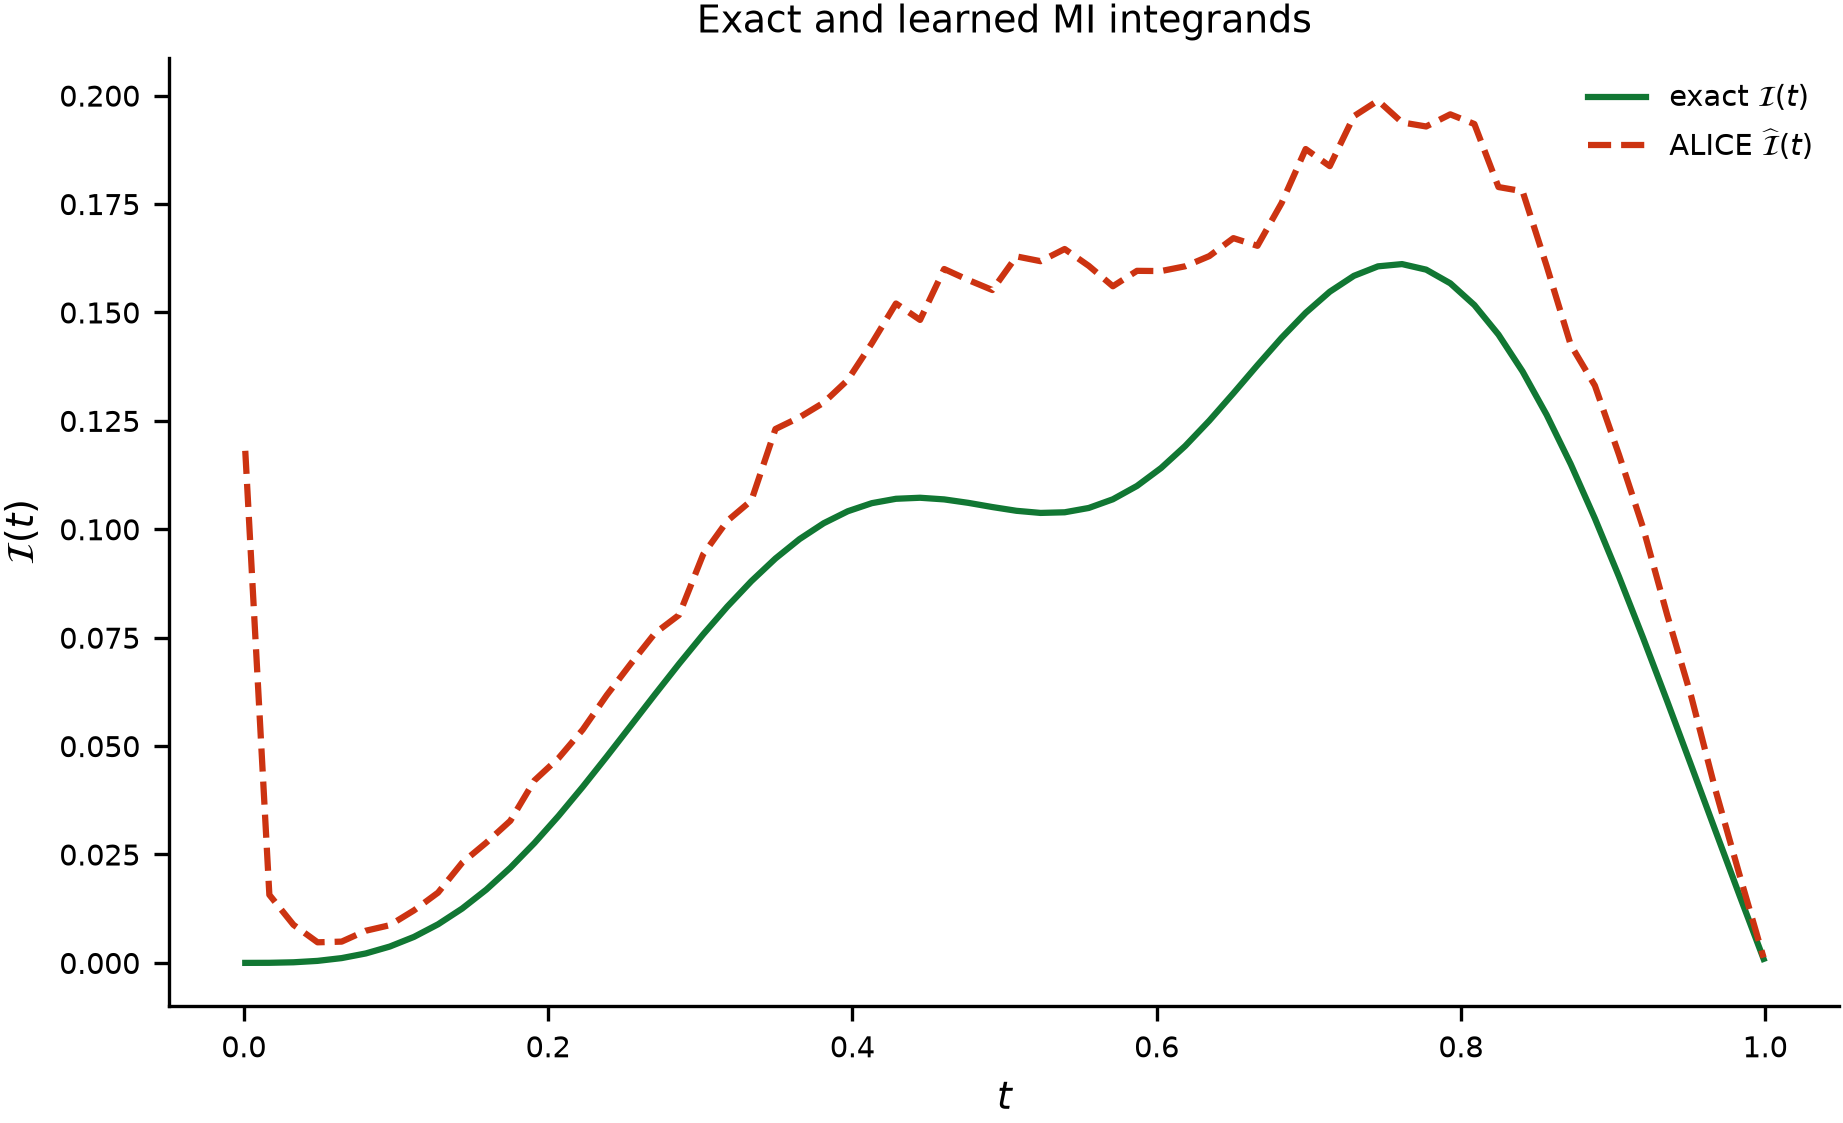

In [ ]:
def model_integrand(t_values, z0_values, epsilon_values):
    results = []
    for t_value in t_values:
        t_column = torch.full((z0_values.shape[0], 1), float(t_value))
        z_full = (1.0 - t_column) * z0_values + t_column * epsilon_values
        z_x = z0_values.clone()
        z_x[:, 0] = z_full[:, 0]
        z_y = z0_values.clone()
        z_y[:, 1] = z_full[:, 1]
        v_full = field(z_full, t_column, torch.ones(2))
        v_x = field(z_x, t_column, torch.tensor([1.0, 0.0]))
        v_y = field(z_y, t_column, torch.tensor([0.0, 1.0]))
        gap = (v_full[:, 0] - v_x[:, 0]).square() + (v_full[:, 1] - v_y[:, 1]).square()
        results.append(gap.mean())
    return torch.stack(results)

model_eval = evaluation_samples[:96]
model_epsilon = torch.randn(model_eval.shape, generator=torch.Generator().manual_seed(SEED + 2))
model_t_grid = torch.linspace(0.02, 0.98, 48)
model_gaps = model_integrand(model_t_grid, model_eval, model_epsilon)
model_integrand_values = model_gaps * (1.0 - model_t_grid) / model_t_grid
exact_model_gaps, _, exact_model_integrand = exact_gap_curves(
    model_t_grid, model_eval.double(), model_epsilon.double(), rho
)
exact_model_integrand = exact_model_integrand.float()
model_mi = estimate_mi_minde(
    model, torch.cat((model_samples, evaluation_samples)), slice(0, 1), slice(1, 2),
    n_context=2048, n_eval=256, n_t_samples=16, chunk=128,
    generator=torch.Generator().manual_seed(SEED + 3),
    return_std=True,
)
print(f'ALICE estimate from public API: {model_mi[0]:.4f} +/- {model_mi[1]:.4f} nats')
print(f'closed-form reference: {true_mi:.4f} nats')

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(model_t_grid, exact_model_integrand, color=COLORS['clean'],
        label=r'exact $\mathcal{I}(t)$')
ax.plot(model_t_grid, model_integrand_values, color=COLORS['conditional'], ls='--',
        label=r'ALICE $\widehat{\mathcal{I}}(t)$')
ax.set(xlabel=r'$t$', ylabel=r'$\mathcal{I}(t)$',
       title='Exact and learned MI integrands')
ax.legend(frameon=False)


## Takeaways

1. A velocity field is a function of both the noisy query and the time $t$.
2. The context identifies the distribution; it is encoded once and reused.
3. A per-coordinate mask lets one frozen model answer three related questions.
4. Mutual information is the area under a weighted squared gap between those fields.
5. The real ALICE output is an approximation to the exact field, not a direct MI scalar.